📊 СТАТИСТИКА:
   - Всего компонент (блоков) найдено: 427
   - Отфильтровано и нарисовано: 11
   - Параметры: Dilation=3, Std Multiplier=1.00, MinSize=200
   - Среднее значение: 16.36, Стандартное отклонение: 43.18, Порог: 59.54


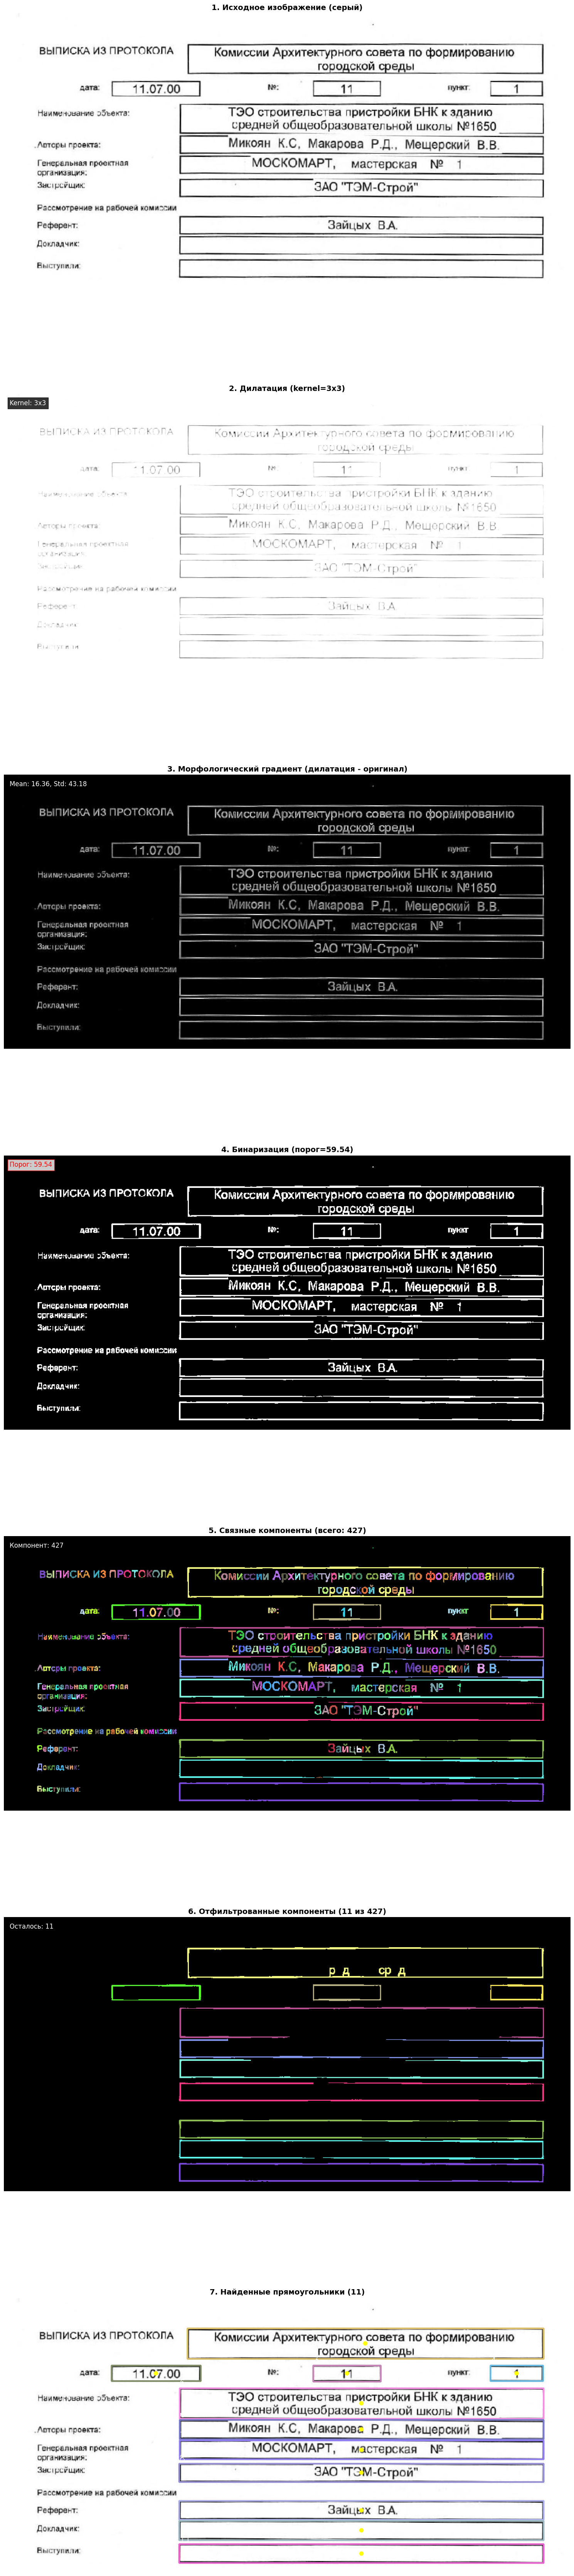


🎯 ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:


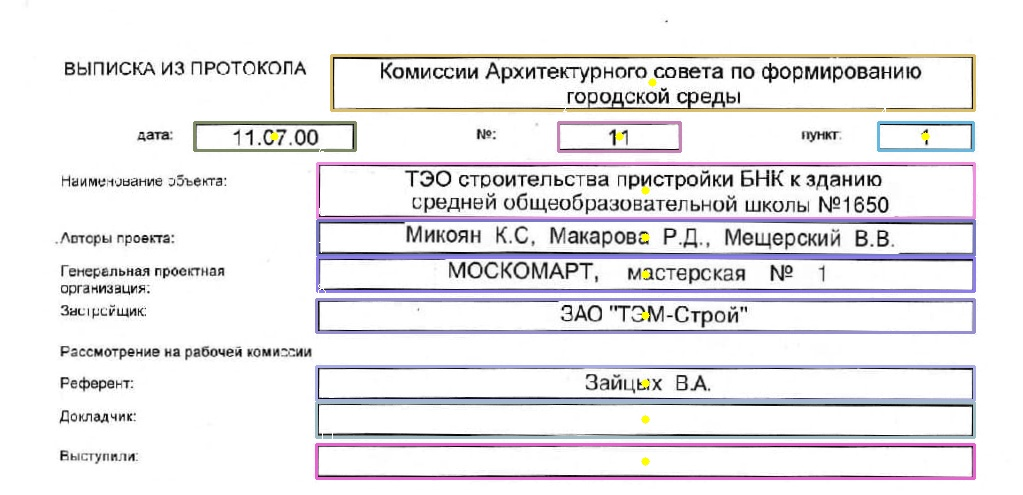


📝 ИНФОРМАЦИЯ О НАЙДЕННЫХ ПРЯМОУГОЛЬНИКАХ:


In [9]:
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as IPImage
from pathlib import Path
import random
from scipy.ndimage import morphology as scipy_morph, label
import matplotlib.pyplot as plt
from io import BytesIO

# ======================= MAIN EXTRACTION FUNCTION WITH DEBUG ==================================
def box_extraction(img_path, dilation_size, std_multiplier, min_size, show_debug=True):
    # 1. Read in grayscale
    img = cv2.imread(img_path, 0)
    if img is None:
        print(f"Ошибка: не удалось загрузить изображение {img_path}")
        return
    
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    # ============ ДЕБАГ: СОХРАНЯЕМ ВСЕ ПРОМЕЖУТОЧНЫЕ ЭТАПЫ ============
    debug_images = []
    debug_names = []
    
    # 1. Исходное изображение
    debug_images.append(img.copy())
    debug_names.append("1. Исходное изображение (серый)")
    
    # 2. Inner morphological gradient.
    footprint = np.ones((dilation_size, dilation_size), dtype=bool)
    
    # 2.1 Дилатация
    dilated = scipy_morph.grey_dilation(img, footprint=footprint)
    debug_images.append(dilated.copy())
    debug_names.append(f"2. Дилатация (kernel={dilation_size}x{dilation_size})")
    
    # 2.2 Вычитание (градиент)
    im = dilated.astype(np.int32) - img.astype(np.int32)
    im_display = np.clip(im, 0, 255).astype(np.uint8)
    debug_images.append(im_display)
    debug_names.append("3. Морфологический градиент (дилатация - оригинал)")
    
    # 3. Binarize using Mean + Std (Dynamic threshold)
    mean, std = im.mean(), im.std()
    t = mean + (std * std_multiplier)
    
    # 3.1 Применяем порог
    im_binary = im.copy()
    im_binary[im_binary < t] = 0
    im_binary[im_binary >= t] = 1
    im_binary_display = (im_binary * 255).astype(np.uint8)
    debug_images.append(im_binary_display)
    debug_names.append(f"4. Бинаризация (порог={t:.2f})")
    
    # 4. Connected components (Scipy label)
    lbl, numcc = label(im_binary)
    
    # 4.1 Визуализация меток (каждая компонента своим цветом)
    lbl_colored = np.zeros((*lbl.shape, 3), dtype=np.uint8)
    for i in range(1, numcc + 1):
        # Генерируем случайный цвет для каждой компоненты
        color = (random.randint(50, 255), random.randint(50, 255), random.randint(50, 255))
        lbl_colored[lbl == i] = color
    debug_images.append(lbl_colored)
    debug_names.append(f"5. Связные компоненты (всего: {numcc})")
    
    # 5. Size threshold and Box extraction
    box_coords = []
    img_boxes = img_color.copy()
    img_components_filtered = np.zeros_like(lbl_colored)
    filtered_count = 0
    
    for i in range(1, numcc + 1):
        py, px = np.nonzero(lbl == i)
        
        # If the component is too small, ignore it
        if len(py) < min_size:
            im_binary[lbl == i] = 0
            continue
        
        filtered_count += 1
        img_components_filtered[lbl == i] = lbl_colored[lbl == i]
        
        xmin, xmax, ymin, ymax = px.min(), px.max(), py.min(), py.max()
        
        # Calculate bounding box
        x, y, w, h = xmin, ymin, (xmax - xmin), (ymax - ymin)
        
        # Generate a random color
        color = (random.randint(100, 255), random.randint(100, 255), random.randint(100, 255))
        
        # Draw the rectangle
        cv2.rectangle(img_boxes, (x, y), (x + w, y + h), color, 2)
        
        # Добавляем центр
        cx = x + w // 2
        cy = y + h // 2
        cv2.circle(img_boxes, (cx, cy), 4, (0, 255, 255), -1)
        
        # Добавляем номер
        cv2.putText(img_boxes, str(filtered_count), (x, y-5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    # 5.1 Компоненты после фильтрации
    debug_images.append(img_components_filtered)
    debug_names.append(f"6. Отфильтрованные компоненты ({filtered_count} из {numcc})")
    
    # 5.2 Финальные боксы
    debug_images.append(img_boxes)
    debug_names.append(f"7. Найденные прямоугольники ({filtered_count})")
    
    # 6. DISPLAY RESULTS
    clear_output(wait=True)
    
    print(f"📊 СТАТИСТИКА:")
    print(f"   - Всего компонент (блоков) найдено: {numcc}")
    print(f"   - Отфильтровано и нарисовано: {filtered_count}")
    print(f"   - Параметры: Dilation={dilation_size}, Std Multiplier={std_multiplier:.2f}, MinSize={min_size}")
    print(f"   - Среднее значение: {mean:.2f}, Стандартное отклонение: {std:.2f}, Порог: {t:.2f}")
    
    # ============ ПОКАЗЫВАЕМ ВСЕ ПРОМЕЖУТОЧНЫЕ ИЗОБРАЖЕНИЯ ============
    if show_debug:
        # Создаем фигуру с вертикальным расположением
        n_images = len(debug_images)
        fig, axes = plt.subplots(n_images, 1, figsize=(15, 10 * n_images))
        
        # Если только одно изображение, делаем его списком для единообразия
        if n_images == 1:
            axes = [axes]
        
        for i, (debug_img, debug_name) in enumerate(zip(debug_images, debug_names)):
            # Определяем, цветное это изображение или нет
            if len(debug_img.shape) == 3:
                axes[i].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
            else:
                axes[i].imshow(debug_img, cmap='gray')
            
            axes[i].set_title(debug_name, fontsize=14, fontweight='bold')
            axes[i].axis('off')
            
            # Добавляем дополнительную информацию на некоторые изображения
            if "Бинаризация" in debug_name:
                axes[i].text(10, 20, f"Порог: {t:.2f}", color='red', fontsize=12, 
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))
            elif "Связные компоненты" in debug_name:
                axes[i].text(10, 20, f"Компонент: {numcc}", color='white', fontsize=12,
                        bbox=dict(facecolor='black', alpha=0.8))
            elif "Отфильтрованные" in debug_name:
                axes[i].text(10, 20, f"Осталось: {filtered_count}", color='white', fontsize=12,
                        bbox=dict(facecolor='black', alpha=0.8))
            elif "Дилатация" in debug_name:
                axes[i].text(10, 20, f"Kernel: {dilation_size}x{dilation_size}", color='white', fontsize=12,
                        bbox=dict(facecolor='black', alpha=0.8))
            elif "Морфологический градиент" in debug_name:
                axes[i].text(10, 20, f"Mean: {mean:.2f}, Std: {std:.2f}", color='white', fontsize=12,
                        bbox=dict(facecolor='black', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    
    # ============ ПОКАЗЫВАЕМ ФИНАЛЬНЫЙ РЕЗУЛЬТАТ ============
    print("\n🎯 ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:")
    is_success, buffer = cv2.imencode(".jpg", img_boxes)
    display(IPImage(data=buffer.tobytes()))
    
    # ============ ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ============
    print("\n📝 ИНФОРМАЦИЯ О НАЙДЕННЫХ ПРЯМОУГОЛЬНИКАХ:")
    for i, coord in enumerate(box_coords):
        x, y, w, h = coord
        area = w * h
        print(f"   {i+1}: x={x}, y={y}, w={w}, h={h}, площадь={area}")

# ======================= SETUP SLIDERS ================================
Path("./output/").mkdir(parents=True, exist_ok=True)

# Слайдеры
slider_dilation = widgets.IntSlider(value=3, min=1, max=9, step=2, description='Dilation Size:')
slider_std = widgets.FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1, description='Std Multiplier:')
slider_min_size = widgets.IntSlider(value=200, min=50, max=5000, step=50, description='Min Size (px):')
checkbox_debug = widgets.Checkbox(value=True, description='Показывать этапы обработки')

# ==================== BIND EVENTS ====================
def update_image(change):
    box_extraction(
        "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/1_rotate.jpg", 
        # "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/modified.png", 
        # "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/4_with_spaces.png", 
        # "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/format2.png", 
        # "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/format3.png", 
        # "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/format3_.png", 
        slider_dilation.value, 
        slider_std.value, 
        slider_min_size.value,
        checkbox_debug.value
    )
    display(widgets.VBox([slider_dilation, slider_std, slider_min_size, checkbox_debug]))

slider_dilation.observe(update_image, names='value')
slider_std.observe(update_image, names='value')
slider_min_size.observe(update_image, names='value')
checkbox_debug.observe(update_image, names='value')

# ==================== ОТРИСОВКА ====================
display(widgets.VBox([slider_dilation, slider_std, slider_min_size, checkbox_debug]))

# Initial run
update_image(None)

 Что показывает отладка:
Этап 1: Исходное изображение
Показывает исходное изображение в градациях серого

Этап 2: Дилатация
Расширение светлых областей. Видно, как увеличиваются границы объектов

Этап 3: Морфологический градиент
Ключевой этап! Показывает разницу между дилатацией и оригиналом

Яркие области = границы объектов

Чем ярче, тем сильнее перепад яркости

Этап 4: Бинаризация
Применение динамического порога (Mean + Std * multiplier)

Белые пиксели = границы

Черные пиксели = фон

Показывает фактический порог

Этап 5: Связные компоненты
Каждая обнаруженная область окрашена в свой цвет

Показывает все объекты до фильтрации

Этап 6: Отфильтрованные компоненты
Только те, что прошли фильтр по размеру

Остаются только большие объекты

Этап 7: Финальные прямоугольники
Итоговый результат с нарисованными прямоугольниками

Центры и номера объектов

